# 3. Modelado con scikit-learn

Este capítulo corresponde a las secciones 9.10.4.3 y 9.10.4.4 del proyecto. Se entrenan los seis modelos con `GridSearchCV` **sin `Pipeline`**, con estos parámetros:

* `cv=3`, el mismo número de pliegues que el `CrossValidator` de PySpark;
* `scoring="roc_auc"`;
* `n_jobs=-1`.

Los modelos se entrenan sobre la matriz de entrenamiento del capítulo 2 y se evalúan en el conjunto de prueba común. Las puntuaciones continuas del conjunto de prueba se guardan para la prueba de DeLong.

In [1]:
import json
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, confusion_matrix, roc_auc_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

import lc_utils as U

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
U.MODELS_SK_DIR.mkdir(exist_ok=True)

## 3.1 Hardware y datos

Para interpretar los tiempos, se declara el hardware en el que se ejecutan ambos entornos (registrado en el capítulo 2). scikit-learn paraleliza la búsqueda de hiperparámetros entre los núcleos lógicos del procesador con `n_jobs=-1`; Spark corre en modo `local[*]` sobre los mismos núcleos.

In [2]:
timings = json.loads((U.DATA_DIR / "timings.json").read_text(encoding="utf-8"))
display(pd.Series(timings["hardware"], name="valor").to_frame())

data = U.sk_train_test()
X_train, X_test, y_train, y_test = data["X_train"], data["X_test"], data["y_train"], data["y_test"]
feature_names = data["prep"].feature_names_
n_train = len(y_train)
prevalence = y_train.mean()
print(f"X_train {X_train.shape}, X_test {X_test.shape}, prevalencia de default en train = {prevalence:.4f}")

,valor
procesador,"Intel64 Family 6 Model 154 Stepping 4, Genuine..."
núcleos físicos,10
núcleos lógicos,12
RAM total (GB),16.8
sistema,Windows 10
Python,3.11.16
Spark,3.5.5


X_train (1076248, 91), X_test (269062, 91), prevalencia de default en train = 0.1996


## 3.2 Modelos y espacios de búsqueda

| Modelo | Clase de scikit-learn | Espacio de búsqueda |
|---|---|---|
| Regresión logística | `LogisticRegression(solver="lbfgs")`, penalización L2 | $C = 1/(\text{regParam} \cdot n)$, con regParam $\in \{10^{-6}, 10^{-5}, 10^{-4}\}$ y $n = 1.076.248$ |
| Árbol de decisión | `DecisionTreeClassifier` | `max_depth` $\in \{5, 10, 15\}$ |
| Bosque aleatorio | `RandomForestClassifier` | `n_estimators` $\in \{10, 50, 100\}$ × `max_depth` $\in \{5, 10, 15\}$ |
| Gradient boosting | `GradientBoostingClassifier(learning_rate=0.1)` | `n_estimators` $\in \{50, 100\}$ × `max_depth` $\in \{3, 5\}$ |
| SVM lineal | `LinearSVC(loss="hinge")` | el mismo $C$ que la regresión logística |
| Naive Bayes | `GaussianNB` | sin búsqueda (configuración por defecto) |

**Equivalencias con PySpark**, que se discuten con detalle en el capítulo 4:

* La regresión logística de scikit-learn minimiza $C\sum_i \ell_i + \tfrac12\lVert w\rVert^2$. La de Spark minimiza $\tfrac1n\sum_i \ell_i + \tfrac{\text{regParam}}{2}\lVert w\rVert^2$. Las dos coinciden cuando $C = 1/(\text{regParam}\cdot n)$. Esa relación es aproximada durante la validación cruzada, porque cada pliegue de ajuste tiene $2n/3$ filas y no $n$.
* `LinearSVC(loss="hinge")` reproduce la pérdida de Spark. El valor por defecto de scikit-learn es la hinge al cuadrado.
* **Pliegues.** `StratifiedKFold(3, shuffle=True, random_state=42)` asigna los pliegues al azar con semilla fija, como hace `CrossValidator` con `seed`. Los pliegues concretos de cada entorno no son idénticos, pero ambos se evalúan sobre el mismo conjunto de prueba.
* **Semillas.** Los modelos estocásticos (árbol, bosque y boosting) usan `random_state=42`.
* **Paralelismo.** En el bosque se usa `n_jobs=1` dentro del estimador. El paralelismo lo aporta `GridSearchCV(n_jobs=-1)`, que ejecuta combinaciones y pliegues simultáneamente sin sobresuscribir los núcleos.

In [3]:
C_grid = [1 / (r * n_train) for r in U.REG_PARAMS]
specs = {
    "LogReg": (LogisticRegression(solver="lbfgs", max_iter=1000), {"C": C_grid}),
    "DecisionTree": (DecisionTreeClassifier(random_state=U.SEED), {"max_depth": [5, 10, 15]}),
    "RandomForest": (RandomForestClassifier(random_state=U.SEED, n_jobs=1),
                     {"n_estimators": [10, 50, 100], "max_depth": [5, 10, 15]}),
    "GradBoost": (GradientBoostingClassifier(learning_rate=0.1, random_state=U.SEED),
                  {"n_estimators": [50, 100], "max_depth": [3, 5]}),
    "LinearSVC": (LinearSVC(loss="hinge", max_iter=1000, random_state=U.SEED), {"C": C_grid}),
    "NaiveBayes": (GaussianNB(), {}),
}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=U.SEED)
pd.DataFrame({"regParam (PySpark)": U.REG_PARAMS, "C (scikit-learn)": C_grid})

,regParam (PySpark),C (scikit-learn)
0,0.000001,0.929154
1,0.000010,0.092915
2,0.000100,0.009292


## 3.3 Entrenamiento con `GridSearchCV`

Para cada modelo se registran:

* `best_params_`, `best_score_` (AUC medio de validación cruzada) y `best_estimator_`;
* el **tiempo de entrenamiento**, que incluye la validación cruzada completa y el reajuste final con todo el conjunto de entrenamiento;
* el **tiempo de predicción** sobre el conjunto de prueba.

La puntuación continua es `predict_proba(X)[:, 1]`. En LinearSVC, que no produce probabilidades, se usa `decision_function(X)`.

**Umbral de decisión.** Con 20 % de default, el umbral por defecto (0,5 para probabilidades, 0 para LinearSVC) hace que casi nunca se prediga la clase minoritaria. Por eso las métricas que dependen de un umbral (accuracy, precision, recall, F1 y la prueba de McNemar) usan un umbral fijado **solo con el conjunto de entrenamiento**: el cuantil $1-\pi$ de las puntuaciones en train, donde $\pi = 0{,}1996$ es la prevalencia de default en train. Con ese umbral, la proporción de préstamos marcados como default en entrenamiento es igual a la tasa real. El conjunto de prueba no interviene en su elección. Al final se incluyen también las métricas con el umbral por defecto.

In [4]:
def scores(model, X):
    return model.decision_function(X) if isinstance(model, LinearSVC) else model.predict_proba(X)[:, 1]

results, cv_tables = {}, {}
test_scores = pd.DataFrame({"id": data["id_test"], U.TARGET: y_test})
train_scores = {}

for name, (estimator, grid) in specs.items():
    t0 = time.time()
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always", ConvergenceWarning)
        gs = GridSearchCV(estimator, grid, cv=cv, scoring="roc_auc", n_jobs=-1, refit=True)
        gs.fit(X_train, y_train)
    t_train = time.time() - t0
    n_conv = sum(issubclass(x.category, ConvergenceWarning) for x in w)

    t0 = time.time()
    s_test = scores(gs.best_estimator_, X_test)
    t_pred = time.time() - t0
    s_train = scores(gs.best_estimator_, X_train)

    thr = U.prevalence_threshold(s_train, prevalence)
    default_thr = 0.0 if name == "LinearSVC" else 0.5
    results[name] = {
        "best_params": {k: float(v) if isinstance(v, float) else v for k, v in gs.best_params_.items()},
        "cv_auc": gs.best_score_, "train_time_s": t_train, "predict_time_s": t_pred,
        "threshold": thr, "default_threshold": default_thr, "convergence_warnings": n_conv,
        "train": U.binary_metrics(y_train, s_train, thr),
        "test": U.binary_metrics(y_test, s_test, thr),
        "test_default_threshold": U.binary_metrics(y_test, s_test, default_thr),
    }
    cv_tables[name] = pd.DataFrame(gs.cv_results_)
    test_scores[name] = s_test
    train_scores[name] = s_train
    joblib.dump(gs.best_estimator_, U.MODELS_SK_DIR / f"{name}.joblib", compress=3)
    print(f"{name:13s} entrenamiento {t_train:7.1f} s | predicción {t_pred:5.2f} s | AUC CV {gs.best_score_:.4f} "
          f"| AUC test {results[name]['test']['roc_auc']:.4f} | {gs.best_params_}"
          + (f" | avisos de convergencia: {n_conv}" if n_conv else ""), flush=True)

test_scores.to_parquet(U.SCORES_SK, index=False)
_ = U.RESULTS_SK.write_text(json.dumps(results, indent=2))

LogReg        entrenamiento    25.4 s | predicción  0.02 s | AUC CV 0.7132 | AUC test 0.7135 | {'C': 0.9291538753149833}


DecisionTree  entrenamiento   136.2 s | predicción  0.05 s | AUC CV 0.7009 | AUC test 0.7029 | {'max_depth': 10}


RandomForest  entrenamiento  1544.8 s | predicción  4.30 s | AUC CV 0.7149 | AUC test 0.7151 | {'max_depth': 15, 'n_estimators': 100}


GradBoost     entrenamiento  7506.0 s | predicción  2.63 s | AUC CV 0.7194 | AUC test 0.7198 | {'max_depth': 5, 'n_estimators': 100}


LinearSVC     entrenamiento  1412.7 s | predicción  0.21 s | AUC CV 0.4866 | AUC test 0.4611 | {'C': 0.9291538753149833} | avisos de convergencia: 1


NaiveBayes    entrenamiento    12.4 s | predicción  0.34 s | AUC CV 0.6393 | AUC test 0.6390 | {}


## 3.4 Resultados de la validación cruzada

In [5]:
rows = []
for name, t in cv_tables.items():
    for _, r in t.iterrows():
        params = {k.replace("param_", ""): r[k] for k in t.columns if k.startswith("param_")}
        rows.append({"modelo": name, "hiperparámetros": ", ".join(f"{k}={v:.4g}" if isinstance(v, float) else f"{k}={v}"
                                                                for k, v in params.items()) or "(por defecto)",
                     "AUC CV medio": r["mean_test_score"], "desv. AUC CV": r["std_test_score"],
                     "tiempo medio de ajuste por pliegue (s)": r["mean_fit_time"], "ranking": r["rank_test_score"]})
cv_all = pd.DataFrame(rows)
cv_all.style.format({"AUC CV medio": "{:.4f}", "desv. AUC CV": "{:.4f}",
                     "tiempo medio de ajuste por pliegue (s)": "{:.1f}"}).hide(axis="index") \
    .apply(lambda r: ["font-weight: bold" if r["ranking"] == 1 else "" for _ in r], axis=1)

modelo,hiperparámetros,AUC CV medio,desv. AUC CV,tiempo medio de ajuste por pliegue (s),ranking
LogReg,C=0.9292,0.7132,0.0007,12.7,1
LogReg,C=0.09292,0.7132,0.0007,11.9,2
LogReg,C=0.009292,0.7132,0.0008,11.9,3
DecisionTree,max_depth=5,0.6956,0.0007,48.8,2
DecisionTree,max_depth=10,0.7009,0.0009,73.5,1
DecisionTree,max_depth=15,0.6685,0.0016,85.4,3
RandomForest,"max_depth=5, n_estimators=10",0.6980,0.0014,58.2,9
RandomForest,"max_depth=5, n_estimators=50",0.6991,0.0014,258.2,8
RandomForest,"max_depth=5, n_estimators=100",0.7005,0.0011,487.9,7
RandomForest,"max_depth=10, n_estimators=10",0.7078,0.0012,105.3,5


In [6]:
best = pd.DataFrame({
    name: {"mejores hiperparámetros": r["best_params"] or "(por defecto)", "AUC CV (best_score_)": r["cv_auc"],
           "tiempo de entrenamiento (s)": r["train_time_s"], "tiempo de predicción (s)": r["predict_time_s"],
           "umbral (train)": r["threshold"]}
    for name, r in results.items()}).T
best

,mejores hiperparámetros,AUC CV (best_score_),tiempo de entrenamiento (s),tiempo de predicción (s),umbral (train)
LogReg,{'C': 0.9291538753149833},0.71321,25.367117,0.024968,0.289404
DecisionTree,{'max_depth': 10},0.700913,136.172428,0.052123,0.294025
RandomForest,"{'max_depth': 15, 'n_estimators': 100}",0.714871,1544.834219,4.295818,0.282356
GradBoost,"{'max_depth': 5, 'n_estimators': 100}",0.719416,7506.046316,2.625311,0.295864
LinearSVC,{'C': 0.9291538753149833},0.486618,1412.731536,0.211276,-1.0
NaiveBayes,(por defecto),0.639307,12.407178,0.340811,0.932804


## 3.5 Métricas en entrenamiento y prueba

In [7]:
def metrics_table(key):
    return pd.DataFrame({n: r[key] for n, r in results.items()}).T

metrics = pd.concat({"train": metrics_table("train"), "test": metrics_table("test")}, axis=1)
metrics.style.format("{:.4f}").highlight_max(axis=0, subset=[("test", "roc_auc"), ("test", "pr_auc"), ("test", "f1")],
                                             props="font-weight: bold; background-color: #d9ead3")

In [8]:
print("Métricas en prueba con el umbral por defecto (0,5 para probabilidades; 0 para LinearSVC):")
metrics_table("test_default_threshold").style.format("{:.4f}")

Métricas en prueba con el umbral por defecto (0,5 para probabilidades; 0 para LinearSVC):


,accuracy,precision,recall,f1,roc_auc,pr_auc
LogReg,0.8025,0.5329,0.0877,0.1506,0.7135,0.3768
DecisionTree,0.8011,0.5138,0.0647,0.1150,0.7029,0.3592
RandomForest,0.8025,0.5989,0.0316,0.0601,0.7151,0.3808
GradBoost,0.8040,0.5684,0.0751,0.1326,0.7198,0.3885
LinearSVC,0.8004,0.0000,0.0000,0.0000,0.4611,0.1824
NaiveBayes,0.6385,0.2925,0.5716,0.3870,0.6390,0.2833


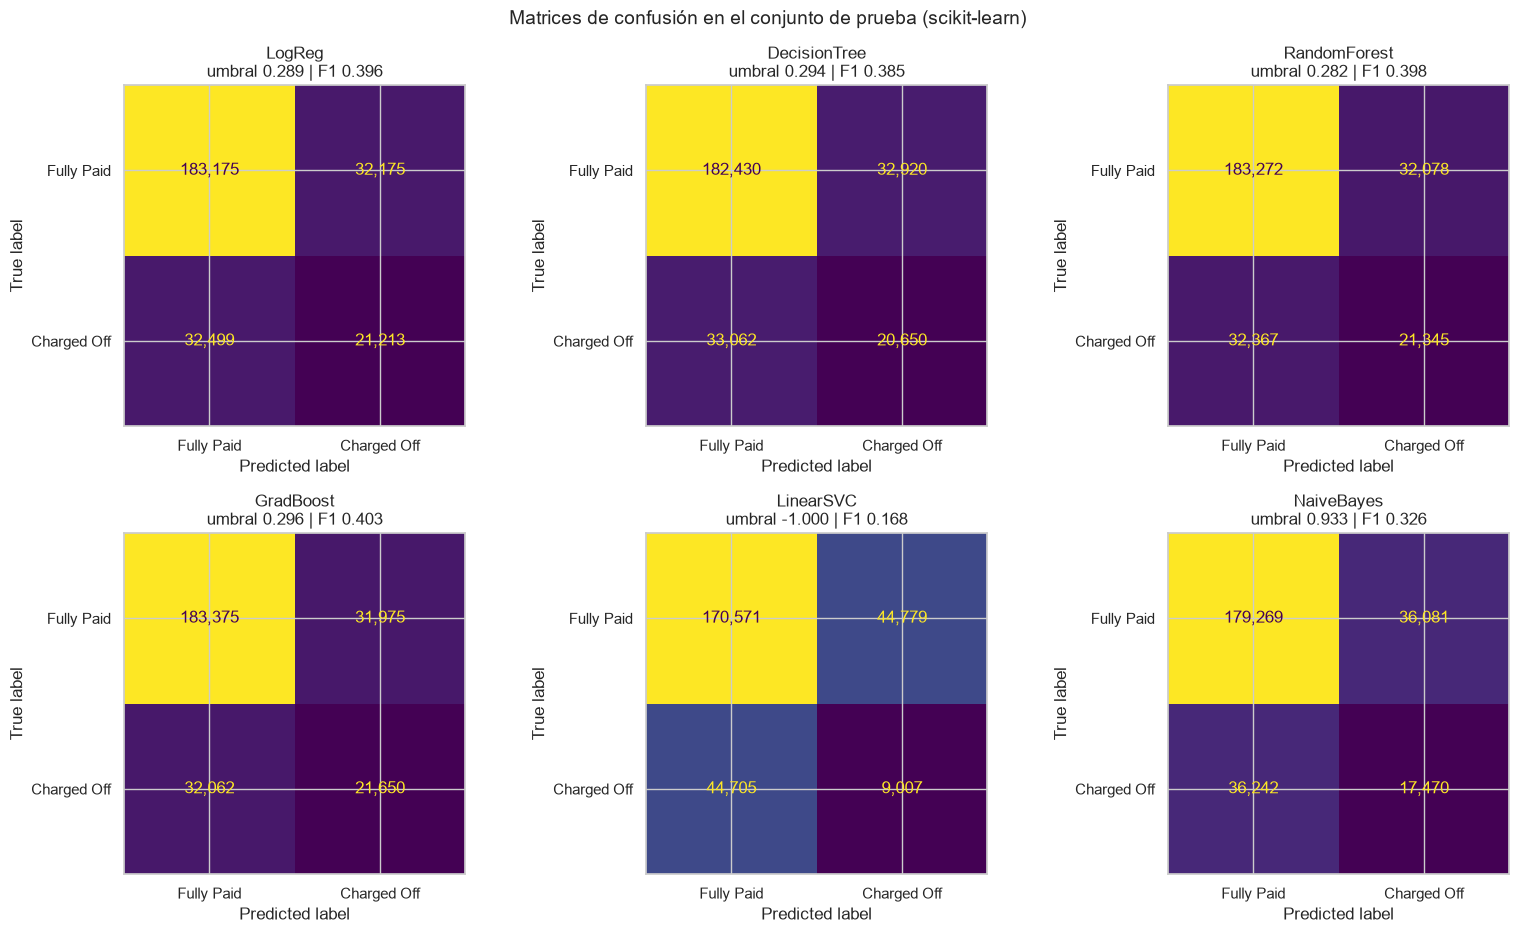

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9.5))
for ax, name in zip(axes.flat, U.MODELS):
    pred = (test_scores[name] >= results[name]["threshold"]).astype(int)
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=["Fully Paid", "Charged Off"]).plot(ax=ax, colorbar=False, values_format=",")
    ax.set_title(f"{name}\numbral {results[name]['threshold']:.3f} | F1 {results[name]['test']['f1']:.3f}")
fig.suptitle("Matrices de confusión en el conjunto de prueba (scikit-learn)", fontsize=14)
plt.tight_layout()
plt.show()

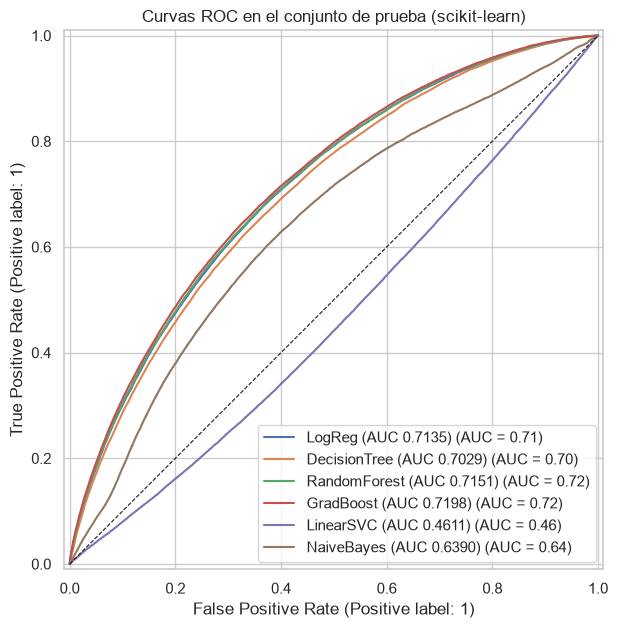

In [10]:
fig, ax = plt.subplots(figsize=(8, 7))
for name in U.MODELS:
    RocCurveDisplay.from_predictions(y_test, test_scores[name], ax=ax,
                                     name=f"{name} (AUC {results[name]['test']['roc_auc']:.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=0.8)
ax.set_title("Curvas ROC en el conjunto de prueba (scikit-learn)")
plt.show()

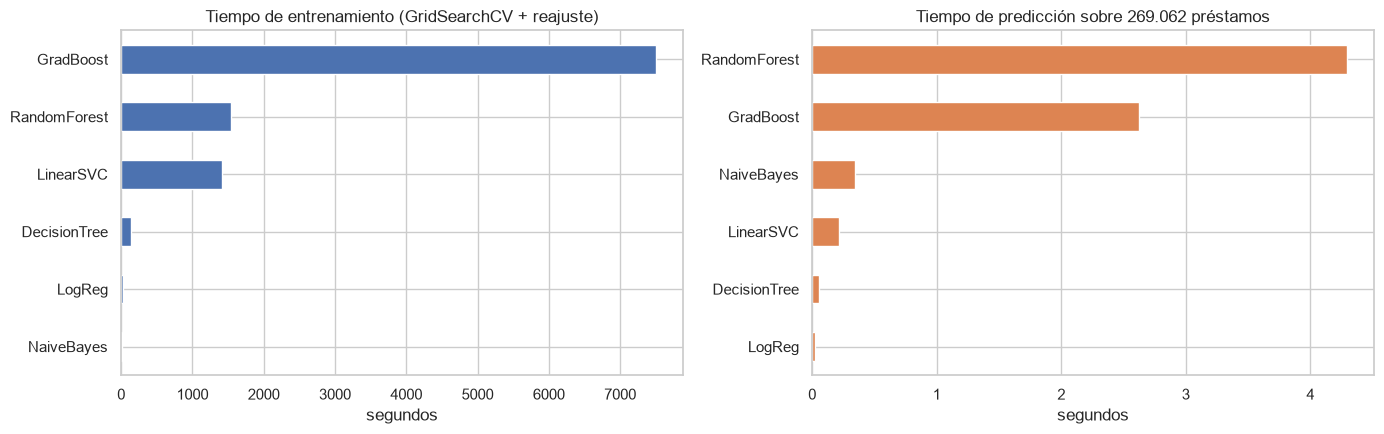

,entrenamiento con validación cruzada,predicción (test)
LogReg,25.37,0.02
DecisionTree,136.17,0.05
RandomForest,1544.83,4.30
GradBoost,7506.05,2.63
LinearSVC,1412.73,0.21
NaiveBayes,12.41,0.34


In [11]:
tt = pd.DataFrame({"entrenamiento con validación cruzada": {n: r["train_time_s"] for n, r in results.items()},
                   "predicción (test)": {n: r["predict_time_s"] for n, r in results.items()}})
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
tt["entrenamiento con validación cruzada"].sort_values().plot.barh(ax=axes[0], color="#4C72B0")
axes[0].set_xlabel("segundos")
axes[0].set_title("Tiempo de entrenamiento (GridSearchCV + reajuste)")
tt["predicción (test)"].sort_values().plot.barh(ax=axes[1], color="#DD8452")
axes[1].set_xlabel("segundos")
axes[1].set_title("Tiempo de predicción sobre 269.062 préstamos")
plt.tight_layout()
plt.show()
tt.round(2)

## 3.6 Diagnóstico de `LinearSVC(loss="hinge")`

scikit-learn solo resuelve la pérdida hinge mediante el **problema dual** (liblinear, descenso por coordenadas). Además, liblinear **regulariza el intercepto**, que trata como una variable más con valor `intercept_scaling=1`. Para entender el resultado de LinearSVC, se compara con dos referencias entrenadas en todo el conjunto de entrenamiento. **No forman parte de los seis modelos**:

* `SGDClassifier(loss="hinge", alpha=regParam)`: la misma pérdida hinge optimizada en el **primal** y sin regularizar el intercepto. Es la formulación más cercana a la de Spark.
* `LinearSVC(loss="squared_hinge", dual=False)`: la pérdida por defecto de scikit-learn, resuelta en el primal.

In [12]:
best_reg = 1 / (results["LinearSVC"]["best_params"]["C"] * n_train)
svc = joblib.load(U.MODELS_SK_DIR / "LinearSVC.joblib")
refs = {
    "LinearSVC hinge (dual, modelo del proyecto)": svc,
    "SGDClassifier hinge (primal)": SGDClassifier(loss="hinge", alpha=best_reg, max_iter=50, tol=1e-4,
                                                  random_state=U.SEED).fit(X_train, y_train),
    "LinearSVC squared_hinge (primal)": LinearSVC(loss="squared_hinge", dual=False,
                                                  C=results["LinearSVC"]["best_params"]["C"]).fit(X_train, y_train),
}
diag = []
for name, m in refs.items():
    s = m.decision_function(X_test)
    diag.append({"modelo": name, "AUC test": roc_auc_score(y_test, s), "‖w‖": np.linalg.norm(m.coef_),
                 "intercepto": float(np.ravel(m.intercept_)[0]), "% test con decisión > 0": 100 * (s > 0).mean()})
pd.DataFrame(diag).set_index("modelo").round(4)

,AUC test,‖w‖,intercepto,% test con decisión > 0
modelo,,,,
"LinearSVC hinge (dual, modelo del proyecto)",0.4611,0.4624,-0.3098,0.0000
SGDClassifier hinge (primal),0.6273,9.5938,-15.5710,0.3304
LinearSVC squared_hinge (primal),0.7135,0.5505,-0.1767,1.2759


## 3.7 Resumen del capítulo

El mejor desempeño en scikit-learn corresponde a `GradientBoostingClassifier` con 100 árboles de profundidad 5, que en el conjunto de prueba alcanza un AUC de 0,7198, un AUC-PR de 0,3885 y un F1 de 0,403. Le siguen el bosque aleatorio (0,7151) y la regresión logística (0,7135). La ventaja de los modelos no lineales sobre el modelo lineal es de apenas 0,006 puntos de AUC, un resultado coherente con el EDA: la señal predictiva se concentra en unas pocas variables (`int_rate`, `term` y el puntaje FICO) cuya relación con el default es esencialmente monótona y aditiva, y un modelo lineal ya la captura en su mayor parte. En todos los modelos, salvo LinearSVC, el AUC de validación cruzada difiere del de prueba en menos de 0,003, lo que confirma que la validación fue un estimador fiable del desempeño fuera de muestra y que la partición aleatoria estratificada produjo conjuntos con la misma distribución. El único sobreajuste apreciable es el del bosque de profundidad 15, cuyo AUC de entrenamiento (0,782) supera en 0,067 al de prueba. La validación cruzada lo selecciona igualmente porque su desempeño de validación sigue siendo el mejor de su espacio de búsqueda.

La elección del umbral resulta determinante para las métricas de clasificación. Con el umbral convencional de 0,5, el recall en prueba se sitúa entre el 3 % y el 9 %, porque los modelos rara vez asignan probabilidades superiores a 0,5 a un problema con 20 % de prevalencia. El umbral fijado en entrenamiento, que iguala la tasa de positivos predichos con la prevalencia, equilibra la precisión y el recall en torno a 0,40 en los mejores modelos. Naive Bayes requiere un umbral de 0,93, síntoma de probabilidades mal calibradas: el supuesto de independencia condicional se viola con variables tan correlacionadas como las de este problema.

LinearSVC con pérdida hinge obtiene un AUC de 0,461, inferior al de un clasificador aleatorio, y su función de decisión es negativa para todos los préstamos. El diagnóstico de la sección 3.6 permite separar dos causas. La primera es propia de la pérdida: con clases muy solapadas y desbalanceadas, el óptimo de la pérdida hinge tiende a una solución casi degenerada, con coeficientes cercanos a cero y un intercepto que clasifica a todos los casos como pagados. La segunda es propia del optimizador: la formulación dual de liblinear, que además regulariza el intercepto, no conserva la dirección de los coeficientes que ordena correctamente a los prestatarios. La misma pérdida optimizada en el primal (`SGDClassifier`) recupera un AUC de 0,627, y la pérdida hinge al cuadrado alcanza 0,7135, prácticamente igual que la regresión logística. En este caso, la validación cruzada solo pudo escoger el valor de $C$ menos desfavorable entre alternativas igualmente inadecuadas.

En términos de cómputo, el entrenamiento completo con validación cruzada tomó 2 h 57 min, de los cuales el 71 % (2 h 5 min) correspondió a gradient boosting. `GradientBoostingClassifier` construye cada árbol de forma secuencial y en un solo hilo, de modo que el único paralelismo disponible es el que ofrece `GridSearchCV` al ajustar simultáneamente combinaciones y pliegues. LinearSVC consumió 24 minutos porque el dual no converge con $C = 0{,}93$, mientras que la regresión logística y Naive Bayes requirieron segundos. En la prueba preliminar, `HistGradientBoostingClassifier` entrenó 100 iteraciones en 22 segundos, con un AUC de validación de 0,718, frente a unos 11 minutos del ajuste equivalente con `GradientBoostingClassifier`. Aunque el enunciado admitía esa sustitución, se conservó el estimador original por fidelidad a la especificación. La diferencia de tiempos se retoma en la reflexión final.